In [2]:
import os
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, GridSearchCV

In [3]:
### TRABAJO PRÁCTICO N°5

In [5]:
#os.chdir(r"C:\Users\Gaelj\OneDrive\Documentos\GitHub\E337_Grupo2\TP5
os.chdir(r"C:\Users\User\Downloads\E337_Grupo2-main\E337_Grupo2-main\TP5")

In [6]:
# Cargemos las variables que utilizamos en 2025

In [7]:
train_2025 = pd.read_csv("train_2025_tp5.csv")
test_2025 = pd.read_csv("test_2025_tp5.csv")

X_train = train_2025.drop(columns="informal")
y_train = train_2025["informal"]

X_test = test_2025.drop(columns="informal")
y_test = test_2025["informal"]

In [8]:
### Ejercicio 1)

In [9]:
# Realizemos primero la busqueda del hiperparámetro para poder realizar el arból en CART:

In [10]:
# Grilla de valores para ccp_alpha
alpha_values = np.linspace(0.0001, 0.01, 30)

param_grid = {
    "ccp_alpha": alpha_values,
    "criterion": ["gini"]
}

tree_cv = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=123),
    param_grid=param_grid,
    cv=10,
    scoring="accuracy"
)

# La búsqueda se hace SOLO con train
tree_cv.fit(X_train, y_train)

best_alpha = tree_cv.best_params_["ccp_alpha"]
print("Mejor ccp_alpha:", best_alpha)
print("Mejor accuracy promedio CV:", tree_cv.best_score_)
print("Error de clasificación promedio CV:", 1 - tree_cv.best_score_)

Mejor ccp_alpha: 0.0001
Mejor accuracy promedio CV: 1.0
Error de clasificación promedio CV: 0.0


In [11]:
# Esta ajustando de manera perfecta, así que sospecho que algo de las variables está generando algún problema 

In [12]:
# Revisar si la variable dependiente quedó dentro de X_train
print(X_train.columns[X_train.columns.str.contains("informal|y|target|ocupado", case=False, regex=True)])

Index([], dtype='object')


In [13]:
# Ver si alguna columna de X_train es idéntica a y_train
for col in X_train.columns:
    if X_train[col].reset_index(drop=True).equals(y_train.reset_index(drop=True)):
        print("Columna idéntica a y_train:", col)

In [14]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

informal
0    481
1    179
Name: count, dtype: int64
informal
0    0.728788
1    0.271212
Name: proportion, dtype: float64


In [15]:
resultados_cv = pd.DataFrame(tree_cv.cv_results_)

resultados_cv[[
    "param_ccp_alpha",
    "mean_test_score",
    "std_test_score"
]]

,param_ccp_alpha,mean_test_score,std_test_score
0,0.000100,1.0,0.0
1,0.000441,1.0,0.0
2,0.000783,1.0,0.0
3,0.001124,1.0,0.0
4,0.001466,1.0,0.0
5,0.001807,1.0,0.0
6,0.002148,1.0,0.0
7,0.002490,1.0,0.0
8,0.002831,1.0,0.0
9,0.003172,1.0,0.0


In [16]:
print("Mejor score CV:", tree_cv.best_score_)
print("Mejor alpha:", tree_cv.best_params_)

Mejor score CV: 1.0
Mejor alpha: {'ccp_alpha': np.float64(0.0001), 'criterion': 'gini'}


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import pandas as pd

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

scores_una_variable = []

for col in X_train.columns:
    modelo_simple = DecisionTreeClassifier(
        max_depth=1,
        random_state=123
    )
    
    score = cross_val_score(
        modelo_simple,
        X_train[[col]],
        y_train,
        cv=cv,
        scoring="accuracy"
    ).mean()
    
    scores_una_variable.append((col, score, 1 - score))

ranking_variables = pd.DataFrame(
    scores_una_variable,
    columns=["variable", "accuracy_cv", "error_cv"]
).sort_values("accuracy_cv", ascending=False)

ranking_variables.head(20)

,variable,accuracy_cv,error_cv
0,CH06,0.728788,0.271212
1,edad2,0.728788,0.271212
2,educ,0.728788,0.271212
3,ingreso_total_familiar,0.728788,0.271212
4,ix_tot,0.728788,0.271212
5,horastrab,0.728788,0.271212
6,CH04,0.728788,0.271212
7,PP07H,0.728788,0.271212
8,PP03C,0.728788,0.271212
9,CAT_OCUP,0.728788,0.271212


In [18]:
arbol_debug = DecisionTreeClassifier(
    random_state=123,
    ccp_alpha=0
)

arbol_debug.fit(X_train, y_train)

importancias = pd.Series(
    arbol_debug.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importancias.head(20)

CAT_OCUP                  0.702895
PP07H                     0.297105
CH06                      0.000000
edad2                     0.000000
educ                      0.000000
ingreso_total_familiar    0.000000
ix_tot                    0.000000
horastrab                 0.000000
CH04                      0.000000
PP03C                     0.000000
CH07                      0.000000
dtype: float64

In [19]:
pd.crosstab(X_train["PP07H"], y_train, margins=True)

informal,0,1,All
PP07H,,,
0,188,179,367
1,293,0,293
All,481,179,660


In [20]:
pd.crosstab(
    [X_train["CAT_OCUP"], X_train["PP07H"]],
    y_train,
    margins=True
)

informal          0    1  All
CAT_OCUP PP07H               
1.0      0       31    0   31
2.0      0      157    0  157
3.0      0        0  179  179
         1      293    0  293
All             481  179  660

In [21]:
# Por lo visto el problema son estas dos variables, PP07H Y CAT_OCUP por que PP07H suele estar vinculada a si la persona tiene o no descuento jubilatorio/aportes en el trabajo. 
# Esa variable normalmente se usa justamente para construir la informalidad laboral.

# Por otro lado CAT_OCUP literalmente indica la categoría ocupacional, así que medio que la variable de informalidad. 

In [22]:
vars_fuga = ["PP07H", "CAT_OCUP"]

X_train = X_train.drop(columns=vars_fuga, errors="ignore")
X_test = X_test.drop(columns=vars_fuga, errors="ignore")

In [23]:
# Vamos de igual manera agregar algunas de las otras variables para cumplir con al menos 15 de ellas. 

In [24]:
# Por lo que veo, voy a tener que cargar de vuelta la base de "ocupados1" como para hacer esto.

In [25]:
ocupados = pd.read_csv('ocupados1.csv')

In [26]:
ocupados.columns

Index(['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC',
       'IPCF', 'CH14', 'CH15_COD', 'CH16_COD', 'PP03C', 'PP04B_COD', 'PP06H',
       'PP07A', 'AÑO', 'CAT_OCUP', 'PP07H', 'informal', 'EMPLEO', 'edad2',
       'CH12', 'CH13', 'educ', 'ingreso_total_familiar', 'horastrab',
       'ix_tot'],
      dtype='object')

In [27]:
var_x =[
    'CH06',
    'edad2',
    'educ',
    'ingreso_total_familiar',
    'IPCF',
    'ix_tot',
    'CH04',
    'PP03C',
    'CH07',
    'CH08',
    'NIVEL_ED',
    'CH12',
    'CH13',
    'PP04B_COD',
    'PP06H',
    'PP07A']

In [28]:
vars_continuas = [
    'CH06',
    'edad2',
    'educ',
    'ingreso_total_familiar',
    'IPCF',
    'ix_tot',
]

vars_binarias = [
    'CH04',
    'PP03C'
]

vars_dummies = [
    'CH07',
    'CH08',
    'NIVEL_ED',
    'CH12',
    'CH13',
    'PP04B_COD',
    'PP06H',
    'PP07A'
]

var_x = vars_continuas + vars_binarias + vars_dummies

len(var_x), var_x

(16,
 ['CH06',
  'edad2',
  'educ',
  'ingreso_total_familiar',
  'IPCF',
  'ix_tot',
  'CH04',
  'PP03C',
  'CH07',
  'CH08',
  'NIVEL_ED',
  'CH12',
  'CH13',
  'PP04B_COD',
  'PP06H',
  'PP07A'])

In [29]:
# Filtrar solamente las observaciones de 2025
ocupados_2025 = ocupados[ocupados['AÑO'] == 2025].copy()

# Crear la matriz X con solo esas variables
X_2025 = ocupados_2025[var_x].copy()

In [30]:
# Ahora, guardemos también por separado la variable dependiente y:

y_2025 = ocupados_2025['informal'].copy()

In [31]:
for v in vars_binarias:
    ocupados_2025[v] = (ocupados_2025[v] == 1).astype(int)

In [32]:
df_dummies = pd.get_dummies(ocupados_2025[vars_dummies], drop_first=True)

In [33]:
# X completa
X_2025 = pd.concat([ocupados_2025[vars_continuas + vars_binarias], df_dummies], axis=1)

# Eliminar filas con NAs
mask = X_2025.notna().all(axis=1) & y_2025.notna()
X_2025 = X_2025[mask]
y_2025 = y_2025[mask]

In [34]:
X2025_train, X2025_test, y2025_train, y2025_test = train_test_split(X_2025, y_2025, test_size=0.30, random_state=444)

In [35]:
# Definamos primero entonces el valor de alpha optimo:

Mejor ccp_alpha: 0.0032653061224489797


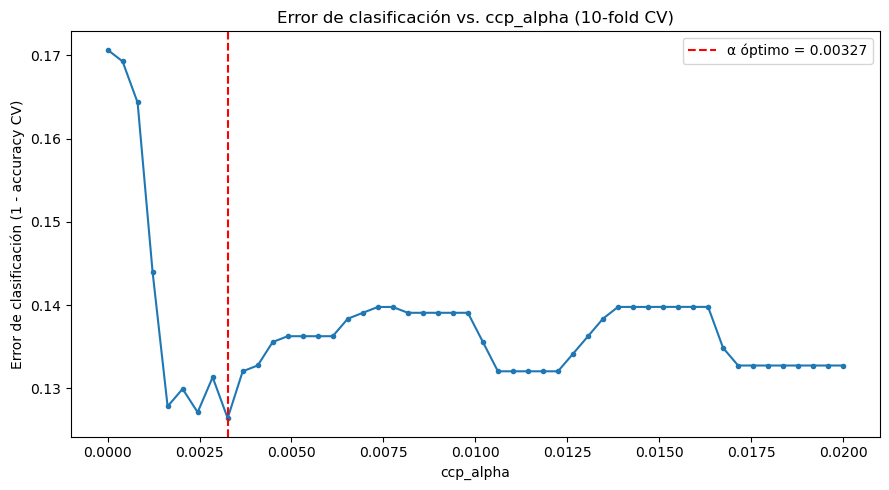

In [36]:
# Grilla de alpha (arrancá con valores pequeños; el árbol se poda mucho con alphas grandes)
alpha_values = np.linspace(0, 0.02, 50)

cv_errors = []

for a in alpha_values:
    tree = DecisionTreeClassifier(ccp_alpha=a, random_state=123)
    scores = cross_val_score(tree, X2025_train, y2025_train, cv=10, scoring='accuracy')
    cv_errors.append(1 - scores.mean())

# Encontrar el alpha óptimo
best_alpha = alpha_values[np.argmin(cv_errors)]
print("Mejor ccp_alpha:", best_alpha)

# Gráfico
plt.figure(figsize=(9, 5))
plt.plot(alpha_values, cv_errors, marker='o', markersize=3)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'α óptimo = {best_alpha:.5f}')
plt.xlabel('ccp_alpha')
plt.ylabel('Error de clasificación (1 - accuracy CV)')
plt.title('Error de clasificación vs. ccp_alpha (10-fold CV)')
plt.legend()
plt.tight_layout()
plt.savefig("cv_error_ccp_alpha.png", dpi=300)
plt.show()

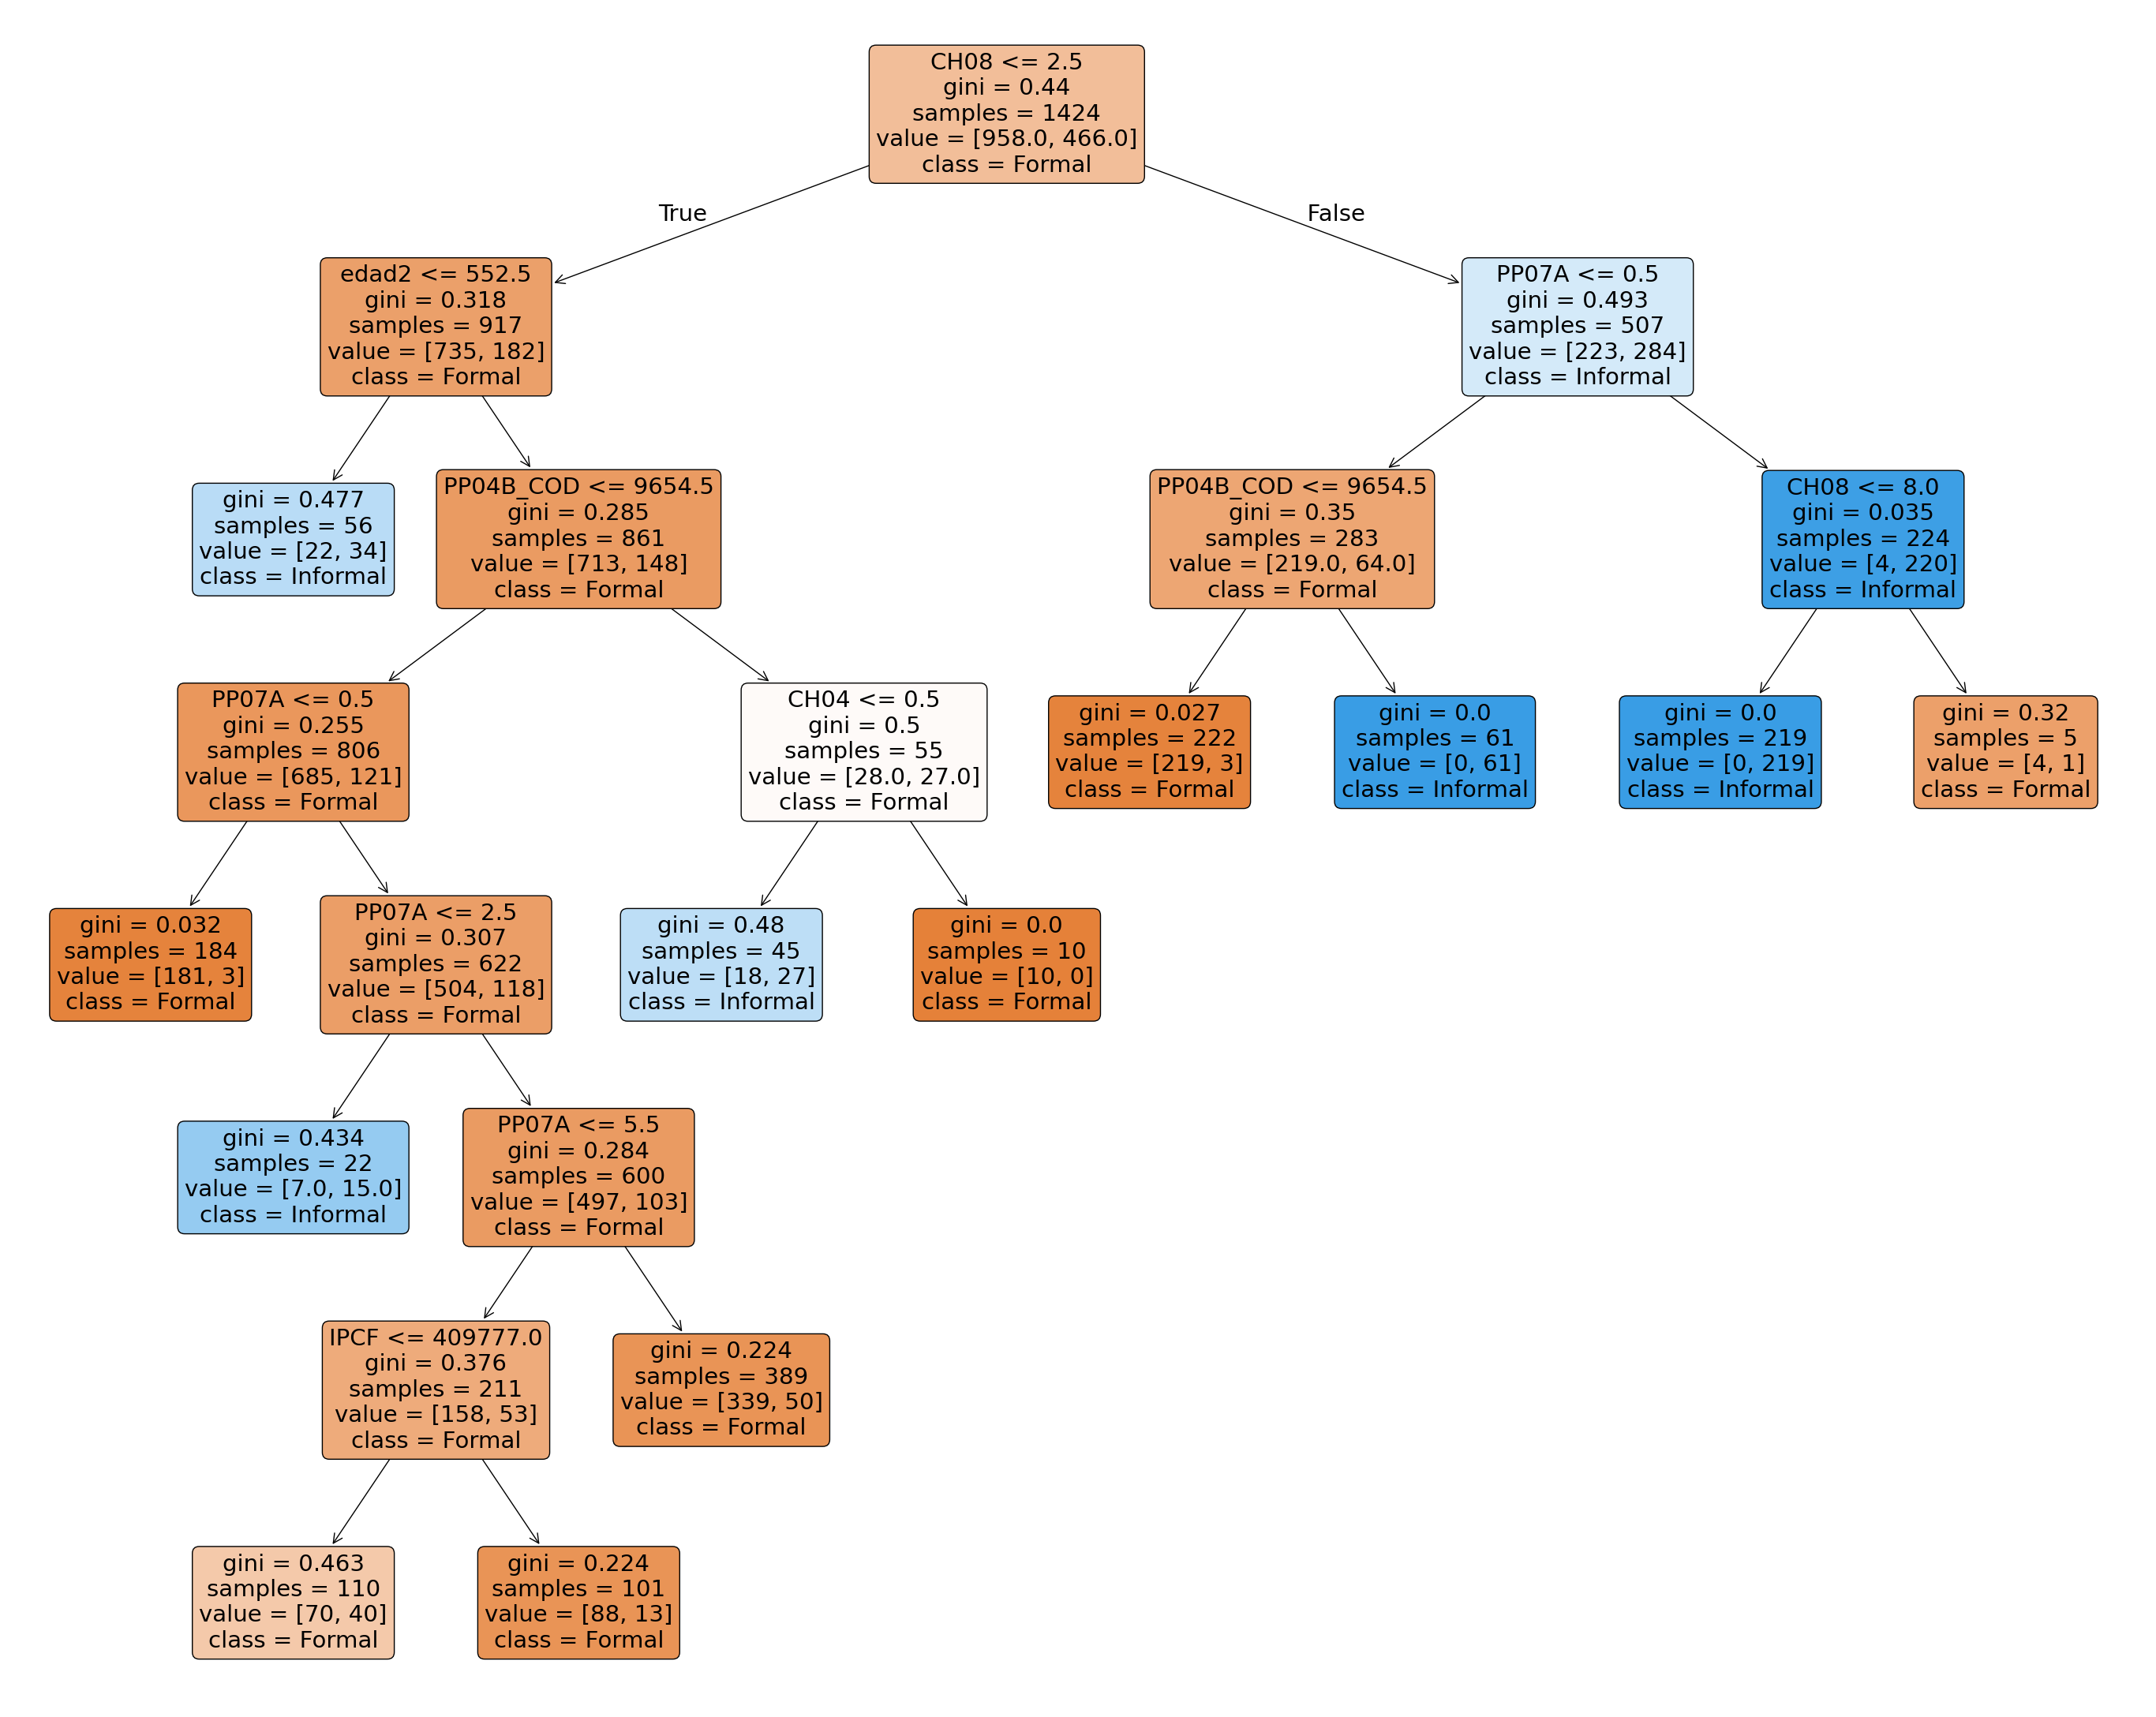

In [37]:
# Planteemos el árbol ahora:

# Árbol final podado con el alpha óptimo encontrado por CV
arbol_podado = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=123)
arbol_podado.fit(X2025_train, y2025_train)

fig = plt.figure(figsize=(35, 28))
plot_tree(arbol_podado,
          feature_names=X2025_train.columns.tolist(), 
          class_names=['Formal', 'Informal'],          
          impurity=True,
          rounded=True,
          filled=True)
fig.savefig("arbol_informal.pdf", bbox_inches='tight')
plt.show()

In [38]:
### Ejercicio 2)

In [39]:
# Realizemos el panel B pedido para este ejercicio al lado del árbol construido arriba:

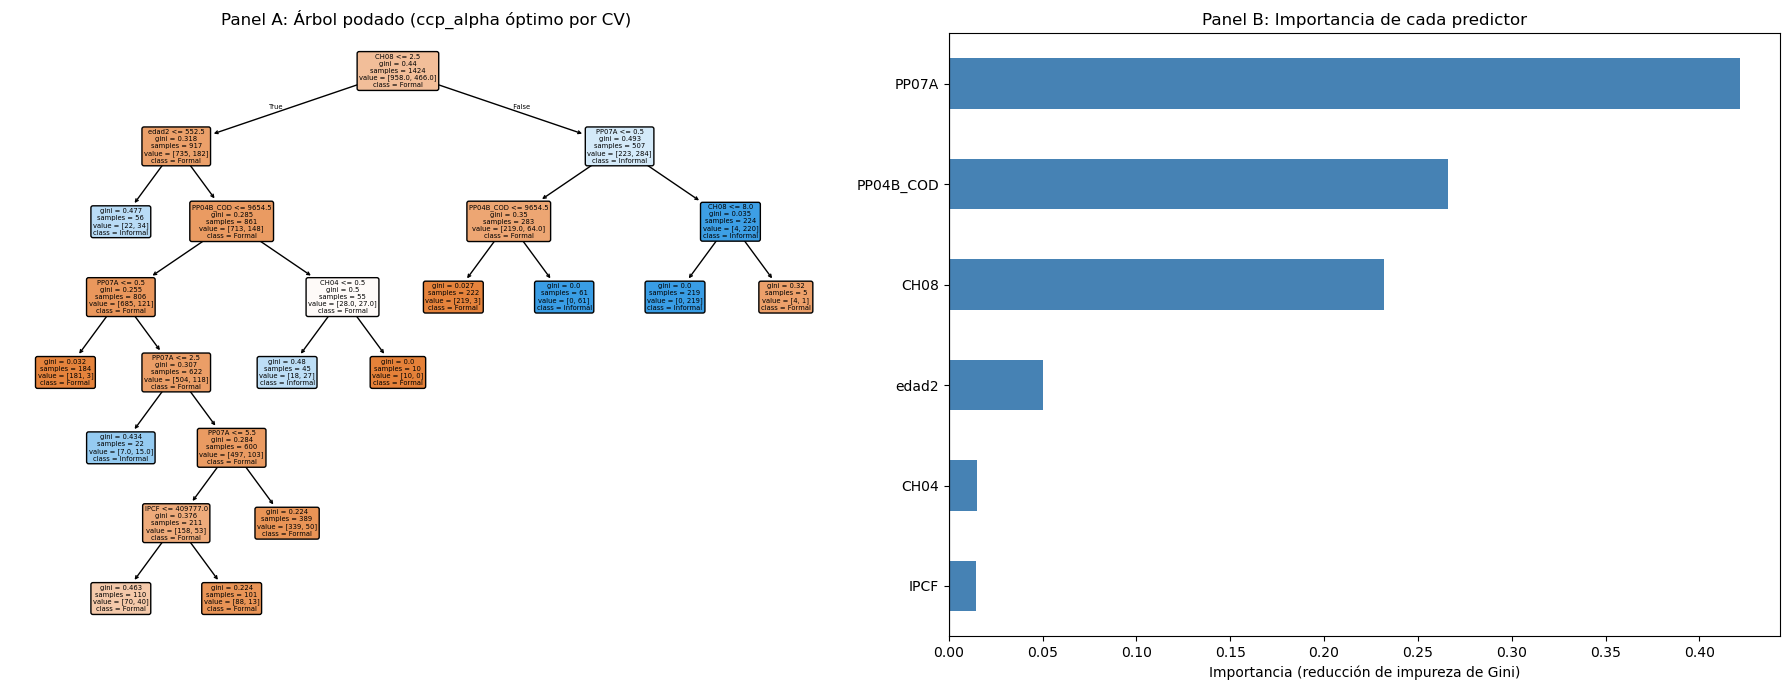

In [40]:
# Panel B: Importancia de variables
importancias = pd.Series(
    arbol_podado.feature_importances_,
    index=X2025_train.columns
).sort_values(ascending=True)  # ascending=True para que el gráfico quede de menor a mayor

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel A: el árbol
plot_tree(arbol_podado,
          feature_names=X2025_train.columns.tolist(),
          class_names=['Formal', 'Informal'],
          impurity=True,
          rounded=True,
          filled=True,
          ax=axes[0])
axes[0].set_title('Panel A: Árbol podado (ccp_alpha óptimo por CV)')

# Panel B: importancia de variables
importancias[importancias > 0].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Panel B: Importancia de cada predictor')
axes[1].set_xlabel('Importancia (reducción de impureza de Gini)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig("ejercicio2_paneles.png", dpi=300, bbox_inches='tight')
plt.show()

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, roc_auc_score,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

# --- Usamos el MISMO split que el árbol (X2025_*) para una comparación justa ---
X_tr = X2025_train.astype(float)
X_te = X2025_test.astype(float)
y_tr = y2025_train
y_te = y2025_test

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# 1) Logit SIN penalidad
logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(penalty=None, class_weight="balanced", max_iter=5000))
]).fit(X_tr, y_tr)

# 2) LASSO (L1) — C óptimo por CV  (C = 1/lambda)
lasso = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf", LogisticRegression(penalty="l1", solver="liblinear",
                                         class_weight="balanced", max_iter=5000))]),
    param_grid={"clf__C": np.logspace(-3, 2, 20)},
    cv=cv, scoring="f1"
).fit(X_tr, y_tr).best_estimator_

# 3) Ridge (L2) — C óptimo por CV
ridge = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf", LogisticRegression(penalty="l2", solver="lbfgs",
                                         class_weight="balanced", max_iter=5000))]),
    param_grid={"clf__C": np.logspace(-3, 2, 20)},
    cv=cv, scoring="f1"
).fit(X_tr, y_tr).best_estimator_

# 4) KNN — K óptimo por CV
knn = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf", KNeighborsClassifier())]),
    param_grid={"clf__n_neighbors": range(3, 41, 2)},
    cv=cv, scoring="f1"
).fit(X_tr, y_tr).best_estimator_

# 5) CART — ya está entrenado (arbol_podado, del ejercicio A)

modelos = {
    "Logit s/penalidad": logit,
    "LASSO": lasso,
    "Ridge": ridge,
    "KNN": knn,
    "CART": arbol_podado,
}

# Probabilidades de informalidad y predicciones con umbral 0.5
proba = {n: m.predict_proba(X_te)[:, 1] for n, m in modelos.items()}
pred  = {n: (proba[n] >= 0.5).astype(int) for n in modelos}

print("LASSO  C óptimo:", lasso.named_steps["clf"].C)
print("Ridge  C óptimo:", ridge.named_steps["clf"].C)
print("KNN    K óptimo:", knn.named_steps["clf"].n_neighbors)

LASSO  C óptimo: 29.763514416313193
Ridge  C óptimo: 29.763514416313193
KNN    K óptimo: 17


In [42]:
filas = []
for n in modelos:
    yp, pr = pred[n], proba[n]
    acc = accuracy_score(y_te, yp)
    filas.append({
        "Modelo": n,
        "Accuracy": acc,
        "1 - Accuracy": 1 - acc,
        "Precision": precision_score(y_te, yp),   # de los que predijo informal, cuántos lo eran
        "Recall": recall_score(y_te, yp),         # de los informales reales, cuántos detectó
        "F1": f1_score(y_te, yp),
        "AUC": roc_auc_score(y_te, pr),
    })

tabla = pd.DataFrame(filas).set_index("Modelo").round(3)
tabla

,Accuracy,1 - Accuracy,Precision,Recall,F1,AUC
Modelo,,,,,,
Logit s/penalidad,0.766,0.234,0.622,0.771,0.688,0.828
LASSO,0.766,0.234,0.622,0.771,0.688,0.828
Ridge,0.766,0.234,0.622,0.771,0.688,0.828
KNN,0.797,0.203,0.765,0.571,0.654,0.833
CART,0.864,0.136,0.859,0.712,0.779,0.906


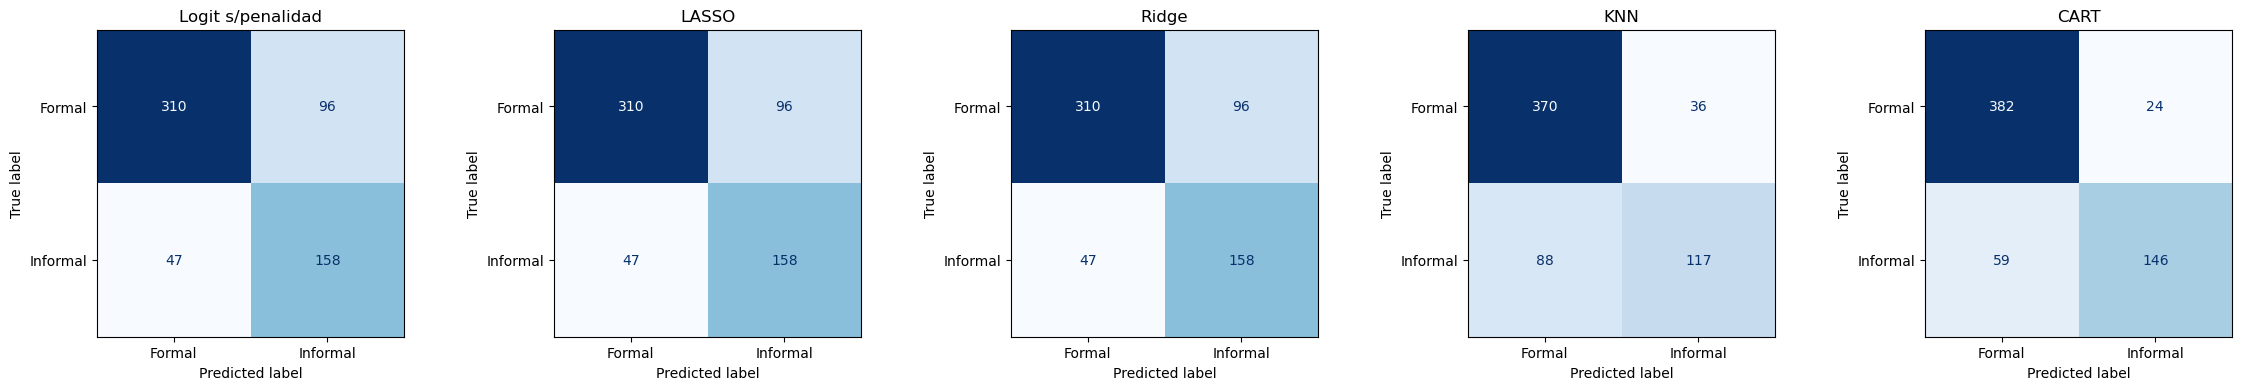

In [43]:
fig, axes = plt.subplots(1, 5, figsize=(23, 4))
for ax, n in zip(axes, modelos):
    cm = confusion_matrix(y_te, pred[n])
    ConfusionMatrixDisplay(cm, display_labels=["Formal", "Informal"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(n)
plt.tight_layout()
plt.savefig("matrices_confusion.png", dpi=300, bbox_inches="tight")
plt.show()

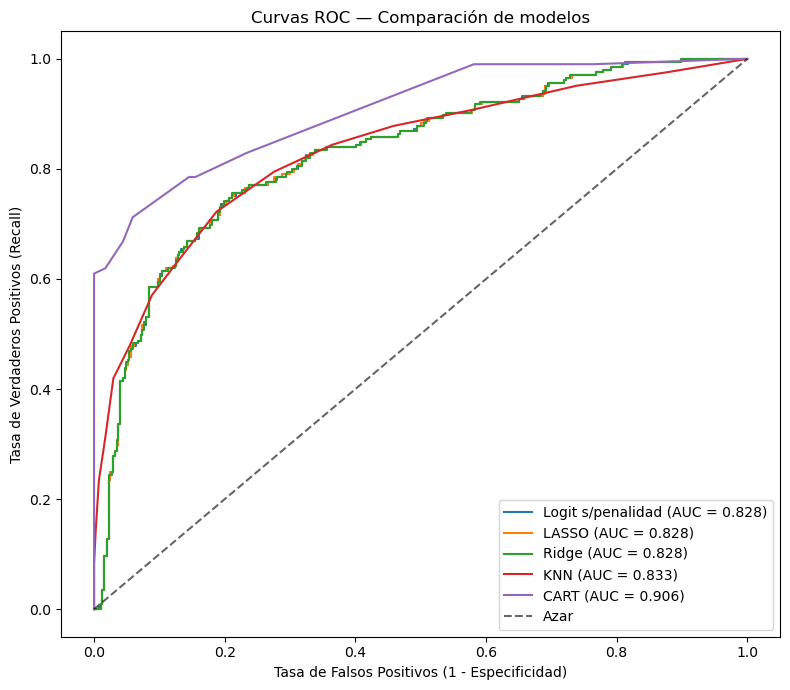

In [44]:
plt.figure(figsize=(8, 7))
for n in modelos:
    fpr, tpr, _ = roc_curve(y_te, proba[n])
    plt.plot(fpr, tpr, label=f"{n} (AUC = {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6, label="Azar")
plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
plt.ylabel("Tasa de Verdaderos Positivos (Recall)")
plt.title("Curvas ROC — Comparación de modelos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("curvas_roc.png", dpi=300, bbox_inches="tight")
plt.show()

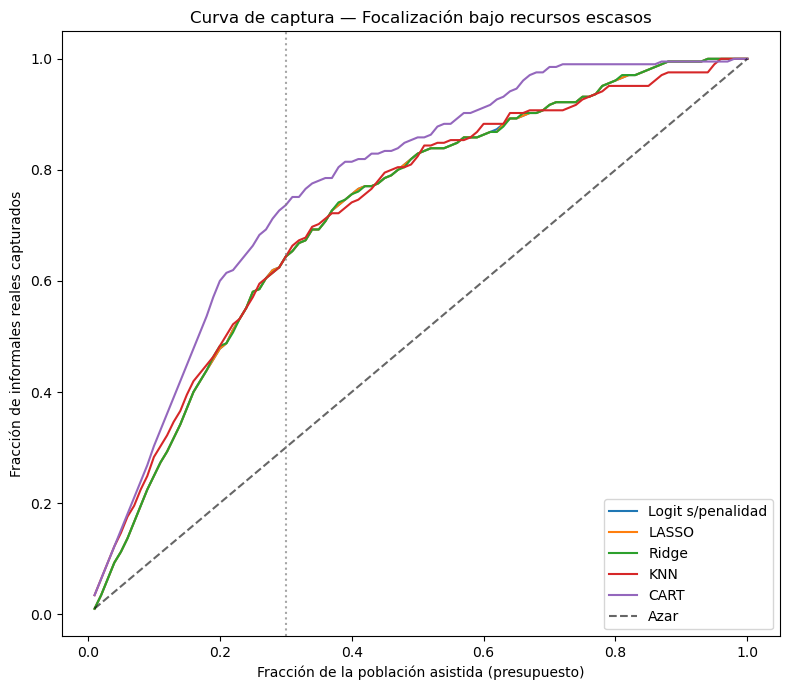

,% informales capturados (presupuesto 30%)
CART,0.737
Logit s/penalidad,0.644
LASSO,0.644
Ridge,0.644
KNN,0.644


In [45]:
# ¿Qué fracción de los informales REALES captura cada modelo
# si solo podemos asistir a los X% con mayor probabilidad predicha?

n_obs = len(y_te)
total_informales = y_te.sum()
budgets = np.linspace(0.01, 1.0, 100)   # fracción de población que podemos asistir

plt.figure(figsize=(8, 7))
captura_30 = {}

for n in modelos:
    # Rankeamos de mayor a menor probabilidad de ser informal
    orden = np.argsort(proba[n])[::-1]
    y_ordenado = y_te.values[orden]
    informales_acumulados = np.cumsum(y_ordenado)

    capturados = []
    for b in budgets:
        k = int(np.ceil(b * n_obs))          # cuántas personas asistimos
        capturados.append(informales_acumulados[k-1] / total_informales)
    plt.plot(budgets, capturados, label=n)

    # Guardamos el valor en un presupuesto de referencia (30%)
    k30 = int(np.ceil(0.30 * n_obs))
    captura_30[n] = informales_acumulados[k30-1] / total_informales

# Línea de "azar": asistir al azar captura proporcionalmente
plt.plot(budgets, budgets, "k--", alpha=0.6, label="Azar")
plt.axvline(0.30, color="gray", linestyle=":", alpha=0.7)
plt.xlabel("Fracción de la población asistida (presupuesto)")
plt.ylabel("Fracción de informales reales capturados")
plt.title("Curva de captura — Focalización bajo recursos escasos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("curva_captura.png", dpi=300, bbox_inches="tight")
plt.show()

# Tabla resumen: % de informales capturados si asistimos al 30% de la población
resumen_30 = pd.DataFrame({
    "% informales capturados (presupuesto 30%)": pd.Series(captura_30)
}).round(3).sort_values("% informales capturados (presupuesto 30%)", ascending=False)
resumen_30